Source: Xavier Dupré

# Scikit-learn

Some simple exercises on *scikit-learn*. The notebook is long for those who are new to machine learning and probably suspense-free for those who have done it before.

## Simple 2D Example

## 1. Synthetic data

**1. Simulate a random data set of size $(n, 1)$ with ``make_regression``.**.



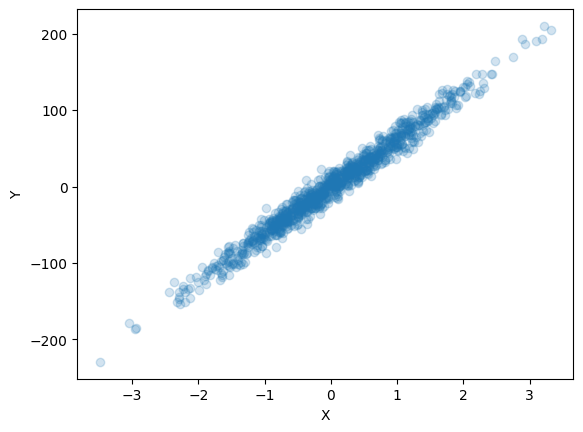

In [ ]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
X, y = make_regression(n_samples=1000, n_features=1, noise=10)

plt.scatter(X, y, alpha=0.2)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

**On the previously generated data, calibrate a linear regression with numpy and calculate the coefficient $R^2$.**

$$\beta = (X^tX)^{-1} X^t y$$  


* Build a ```cost``` function for the linear regression
* Build a ```predict``` function using the features and the coefficient of the model
* Build a ```fit``` function with a gradient descent algorithm to minimize the cost function over the training dataset. 

## Gradient Descent

Gradient Descent is an optimization algorithm used to minimize the cost function in machine learning and deep learning models. It is an iterative algorithm that starts with an initial set of parameters and updates them to minimize the cost function.

### Steps of Gradient Descent:

1. **Initialize Parameters**: Start with initial values for the parameters (weights and biases).

2. **Compute the Cost Function**: Calculate the cost function, which measures how well the model's predictions match the actual data.

3. **Compute the Gradient**: Calculate the gradient of the cost function with respect to each parameter. The gradient is a vector of partial derivatives that points in the direction of the steepest increase in the cost function.

4. **Update Parameters**: Update the parameters by moving them in the opposite direction of the gradient. The size of the step is determined by the learning rate.

    $$
    \theta = \theta - \alpha \frac{\partial J(\theta)}{\partial \theta}
    $$

    where:
    - $\theta$ is the parameter vector (randomly initialized).
    - $\alpha$ is the learning rate.
    - $\frac{\partial J(\theta)}{\partial \theta}$ is the gradient of the cost function (in our case it is the gradient of the Mean Squared Error).
    - $ J(\theta) = \frac{1}{N}\sum (\hat{y} - y)^2 = \frac{1}{N} \sum (x^T \theta - y)^2$
    - $\frac{\partial J(\theta)}{\partial \theta} = \frac{\partial }{\partial \theta} (\frac{1}{N} \sum (x^T \theta - y)^2) =\frac{1}{N} \frac{\partial }{\partial \theta} (\sum ((x^2)^T \theta^2 - 2x^T\theta y + y^2)) = \frac{1}{N}  (\sum (2(x^2)^T \theta - 2x^Ty)) =\frac{2}{N} \sum x  (\hat{y} - y)  $ 

5. **Repeat**: Repeat steps 2-4 until the cost function converges to a minimum or a predefined number of iterations is reached.

### Types of Gradient Descent:

1. **Batch Gradient Descent**: Uses the entire dataset to compute the gradient at each step. It can be slow for large datasets.

2. **Stochastic Gradient Descent (SGD)**: Uses one training example to compute the gradient at each step. It is faster but can have high variance in the updates.

3. **Mini-Batch Gradient Descent**: Uses a small batch of training examples to compute the gradient at each step. It balances the speed of SGD and the stability of Batch Gradient Descent.

### Advantages:

- Simple to implement.
- Efficient for large datasets.
- Can be used for various types of machine learning models.

### Disadvantages:

- Requires careful tuning of the learning rate.
- Can get stuck in local minima.
- May require many iterations to converge.

Gradient Descent is a fundamental algorithm in machine learning and is widely used for training models, especially in deep learning.

In [ ]:
import numpy as np

# Cost function
def MSE(y_pred, y):
    return np.mean((y_pred - y)**2)

# Gradient function for the MSE
def gradient(X, y, theta):
    y_pred = predict(X, theta)
    return 2*X.T.dot(y_pred - y) / y.size

# Prediction function
def predict(X, theta):
    return X.dot(theta)

# Gradient descent
def fit(X, y, lr, epochs):
    X = np.c_[np.ones(X.shape[0]), X]
    theta = np.random.randn(X.shape[1])
    for _ in range(epochs):
        grad = gradient(X, y, theta)
        theta -= lr * grad
    return theta

# Fit the model
theta = fit(X, y, lr=0.1, epochs=1000)
print(theta)

: 

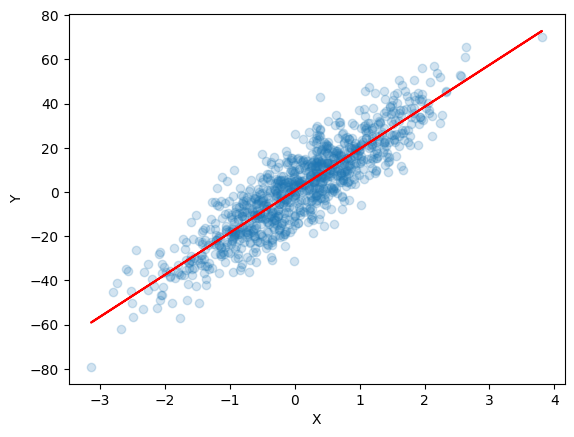

In [19]:
# Plot the regression line
plt.scatter(X, y, alpha=0.2)
plt.xlabel('X')
plt.ylabel('Y')
plt.plot(X, predict(np.c_[np.ones(X.shape[0]), X], theta), color='red')
plt.show()

#### Now try the same thing in sklearn ! (look at the documentation to see how to to it)

Coefficients: [18.98503024]
Intercept: 0.5158760776593714


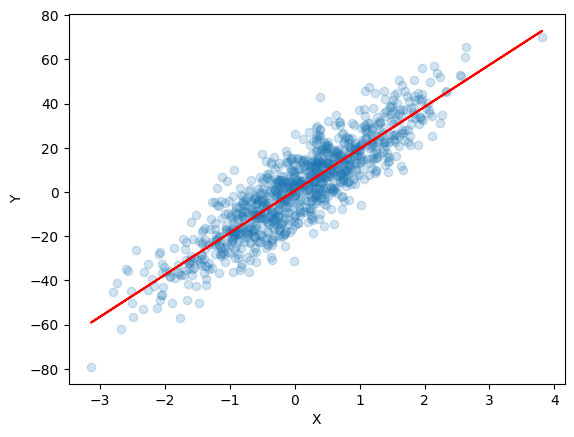

In [ ]:
from sklearn.linear_model import LinearRegression

# Create and fit the model
model = LinearRegression()
model.fit(X, y)

# Print the coefficients
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Plot the regression line
plt.scatter(X, y, alpha=0.2)
plt.xlabel('X')
plt.ylabel('Y')
plt.plot(X, predict(np.c_[np.ones(X.shape[0]), X], theta), color='red')
plt.plot(X, model.predict(X), color='green')
plt.show()


# Multi dimensional data

## 1. Synthetic data

**1. Simulate a random data set of size $(n, 2)$ with ``numpy.random``.**.

**2. Store the sample in a variable $X$.**.
    

Subsequently, consider $X = (X_1, X_2)$.



In [ ]:
import numpy as np

n = 1000
X = np.random.randn(n, 2)
X[:5]

array([[0.75175151, 0.73546978],
       [0.91627199, 0.25311522],
       [0.18624553, 0.21910963],
       [0.44185181, 0.43265768],
       [0.45276543, 0.58562316]])

From $X$, calculate $$Y = 3 X_1-2X_2^2 + \epsilon$$ 
with $\epsilon \in [0,1]$

In [ ]:
y = X[:, 0] * 3 - 2 * X[:, 1] ** 2 + np.random.rand(n)
y[:5]

array([1.21529434, 3.54993257, 1.12522793, 1.84709175, 1.41411321])

## 2. Train, validation, test

When training a model, it is customary to divide the training data set into 2 parts:

- A training part (*train set*), to calibrate the model
- A validation part (*validation set*), to evaluate the model during training.

To test the generalizability of the model, once training on the training set is complete, the model is **only** evaluated on (we NEVER use the test set during training):
- An evaluation set (*test set*)


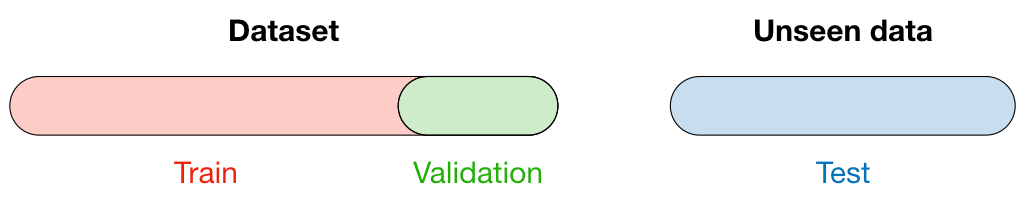

**Perform this distribution in the training set with variables $X_{train}, Y_{train}$ (X_train, Y_train) and in the validation set $X_{test}, Y_{test}$ (X_test, Y_test) with an 80/20 distribution (train/test).**

In [ ]:
# Without sklearn
n = X.shape[0]

ratio = 0.8

n_train = int(ratio*n)

X_train = X[:n_train]
X_test = X[n_train:]

y_train = y[:n_train]
y_test = y[n_train:]
print(X_train.shape, X_test.shape, y_train.shape,y_test.shape)

(800, 2) (200, 2) (800,) (200,)


In [ ]:
# With sklearn
from sklearn.model_selection import train_test_split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.8)

print(X_train.shape, X_test.shape, y_train.shape,y_test.shape)

(800, 2) (200, 2) (800,) (200,)


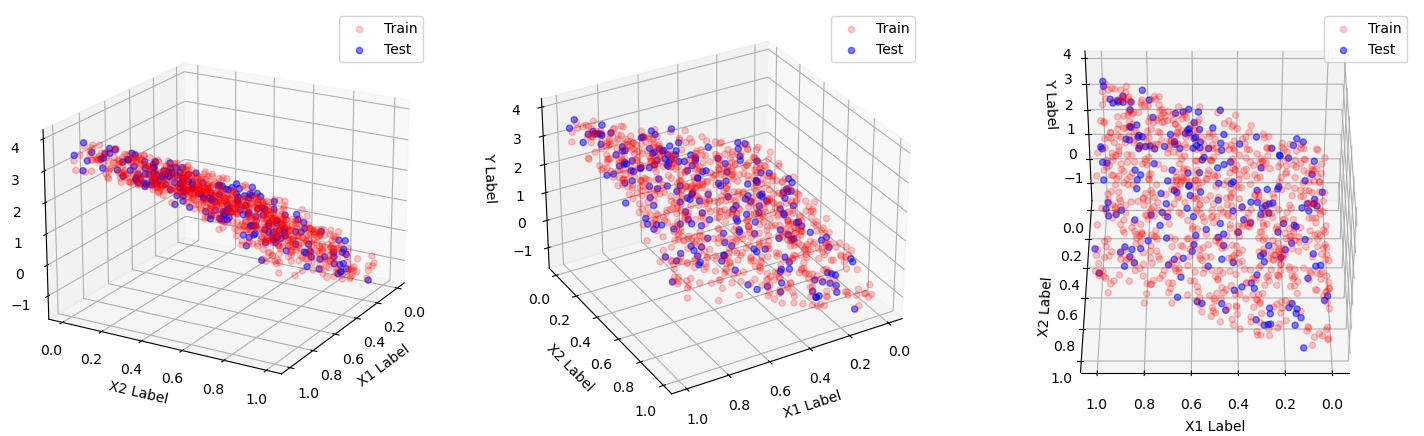

In [ ]:
# 3D Plot of data with train and test labels
import matplotlib.pyplot as plt

# X_train.shape = (800, 2)
# X_test.shape = (200, 2)
# y_train.shape = (800,)
# y_test.shape = (200,)

fig = plt.figure(figsize=(18, 6))

# First view
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X_train[:,0], X_train[:,1], y_train, c='r', marker='o', alpha=0.2)
ax1.scatter(X_test[:,0], X_test[:,1], y_test, c='b', marker='o', alpha=0.5)
ax1.set_xlabel('X1 Label')
ax1.set_ylabel('X2 Label')
ax1.set_zlabel('Y Label')
ax1.legend(['Train', 'Test'])
ax1.view_init(elev=20, azim=30)  # Change elevation and azimuth

# Second view
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(X_train[:,0], X_train[:,1], y_train, c='r', marker='o', alpha=0.2)
ax2.scatter(X_test[:,0], X_test[:,1], y_test, c='b', marker='o', alpha=0.5)
ax2.set_xlabel('X1 Label')
ax2.set_ylabel('X2 Label')
ax2.set_zlabel('Y Label')
ax2.legend(['Train', 'Test'])
ax2.view_init(elev=30, azim=60)  # Change elevation and azimuth

# Third view
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(X_train[:,0], X_train[:,1], y_train, c='r', marker='o', alpha=0.2)
ax3.scatter(X_test[:,0], X_test[:,1], y_test, c='b', marker='o', alpha=0.5)
ax3.set_xlabel('X1 Label')
ax3.set_ylabel('X2 Label')
ax3.set_zlabel('Y Label')
ax3.legend(['Train', 'Test'])
ax3.view_init(elev=40, azim=90)  # Change elevation and azimuth

plt.show()

## 3. Linear Regression

**On the previously generated data, calibrate a linear regression with sklearn and calculate the coefficient $R^2$.**

$$\beta = (X^tX)^{-1} X^t y$$  
    


* Calibrate a linear regression using previously computed functions in numpy

In [27]:

theta = fit(X_train, y_train, lr=0.1, epochs=10000)
print(theta)



[ 0.83775336  2.96380387 -1.99859117]


* Calibrate a linear regression using sklearn

In [28]:
from sklearn.linear_model import LinearRegression
LR = LinearRegression()
LR.fit(X_train,y_train)
print("Coefficients:", LR.coef_)
print("Intercept:", LR.intercept_)
print("R^2 score:", LR.score(X_train,y_train))

Coefficients: [ 2.96380387 -1.99859117]
Intercept: 0.8377533598766186
R^2 score: 0.9118469738656444


* Display the model's coefficients

In [29]:
print(LR.coef_,LR.intercept_)

[ 2.96380387 -1.99859117] 0.8377533598766186


* Calculate the $R^2$

In [30]:
from sklearn.metrics import r2_score
y_train_pred = LR.predict(X_train)
r2_score(y_train, y_train_pred)

0.9118469738656444

In [31]:
y_test_pred = LR.predict(X_test)
r2_score(y_test, LR.predict(X_test))

0.9247251730127134

**What can you say about the choice of model (**Linear Regression**) given the complexity of the data ($Y = 3 X_1 - 2 X_2^2 + \epsilon$)?**

## 4. Polynomial Features

→*The linear model does not capture the non-linear effects ($X_2^2$) present in the explanatory variables.
In this case, we need to perform a transformation $$Z = X_2^2$$ and model $$Y = 3 X_1 - 2 Z + \epsilon$$*

*This response variable is linear and can be modeled by Linear Regression.

*The function [``PolynomialFeatures``](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) can be used to perform this transformation $Z = X_2^2$.


**Use ``PolynomialFeatures`` to perform this transformation.**
    


In [32]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures()

poly.fit(X_train)

X_train2 = poly.transform(X_train)


**Calibrate a linear regression on the new data.**


In [33]:
LR2 = LinearRegression(fit_intercept=False)
LR2.fit(X_train2, y_train)

LinearRegression(fit_intercept=False)


**Calculate the $R^2$ and compare it to the previous model.**
    


In [34]:
score2 = r2_score(y_test, LR2.predict(poly.transform(X_test)))
score2

0.9359753909453459

## 5. Random forest

**Calibrate a random forest on previously generated data.**

In [35]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

RandomForestRegressor()

**Give the model's $R^2$ coefficient.**
    

In [36]:
r2_score(y_test, rf.predict(X_test))

0.9208052813477782

The linear model is the best model in our case, since the data have been constructed in this way. It is expected that the $R^2$ will not be (significantly) higher.

**Calibrate the model on polynomial features.**

In [37]:
rf2 = RandomForestRegressor()
rf2.fit(X_train2, y_train)
r2_score(y_test, rf2.predict(poly.transform(X_test)))

0.9199976627600293

## 6. With new data

**Compare the two models on the following data. What do you notice? Explain why?**

In [51]:
X_test2 = np.random.rand(n, 2) + 0.5
y_test2 = X_test2[:, 0] * 3 - 2 * X_test2[:, 1] ** 2 + np.random.rand(n)

In [52]:
res = []
for model in [LR, LR2, rf, rf2]:
    name = model.__class__.__name__
    try:
        pred = model.predict(X_test)
        pred2 = model.predict(X_test2)
    except Exception:
        pred = model.predict(poly.transform(X_test))
        pred2 = model.predict(poly.transform(X_test2))
        name += " + X^2"
    res.append(dict(name=name, r2=r2_score(y_test, pred),
                    r2_jeu2=r2_score(y_test2, pred2)))

import pandas
df = pandas.DataFrame(res)
df

,name,r2,r2_jeu2
0,LinearRegression,0.924725,0.694792
1,LinearRegression + X^2,0.935975,0.956660
2,RandomForestRegressor,0.920805,0.486410
3,RandomForestRegressor + X^2,0.919998,0.481285


The only model that performs well is linear regression with polynomial features. As it is equivalent to the theoretical model, it is normal that it comes close, even if its coefficients are not identical to the theoretical model (more data would be needed for it to converge).

## 7. Plots
The scatterplot of the first and second game, the predictions of the two models, a legend, a title... with [pandas](https://pandas.pydata.org/) or directly with [matplotlib](https://matplotlib.org/) as you wish.

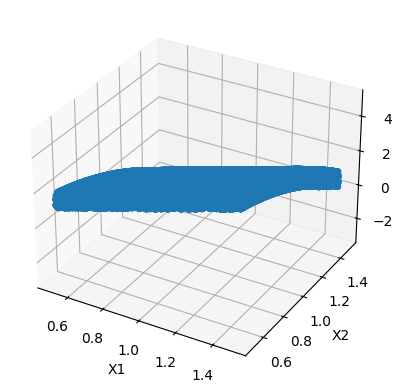

In [58]:
import matplotlib.pyplot as plt
from matplotlib import cm

# Task 1: Generate a Scatter Plot
X0, X1 = np.meshgrid(X_test2[:, 0], X_test2[:, 1])
Y0=X0 *3 - 2*X1**2 + np.random.rand(n)
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.scatter(X0, X1, Y0, linewidth=0)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('Y')

plt.show()

**Plot $Y$ for a fixed $X_2$, then $Y$ for a fixed $X_1$**.

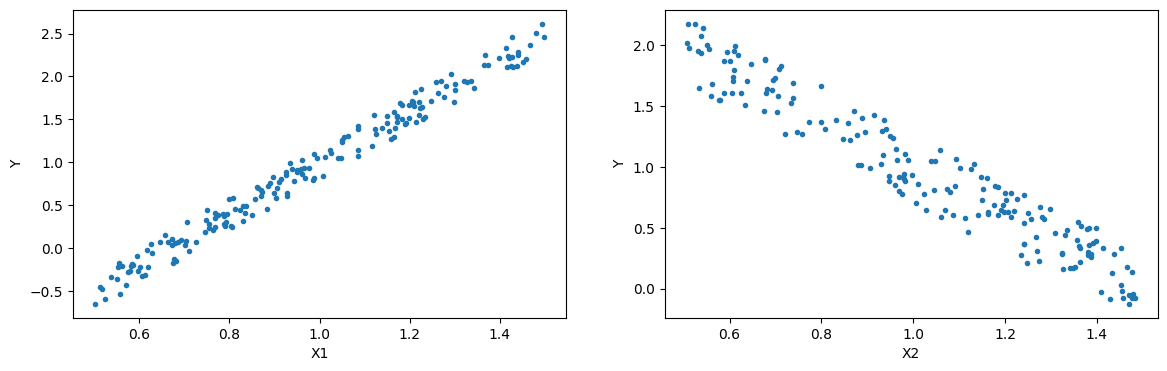

In [59]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

a, b = 0.9, 1.1
index1 = (X_test2[:, 0] >= a) & (X_test2[:, 0] <= b)
index2 = (X_test2[:, 1] >= a) & (X_test2[:, 1] <= b)
yth = X_test2[:, 0] * 3 - 2 * X_test2[:, 1]

ax[0].set_xlabel("X1")
ax[0].set_ylabel("Y")
ax[0].plot(X_test2[index2, 0], yth[index2], '.', label='Y théorique')

ax[1].set_xlabel("X2")
ax[1].set_ylabel("Y")
ax[1].plot(X_test2[index1, 1], yth[index1], '.', label='Y théorique')

**For each model, plot the predictions on the X_test2 set and add a legend with the name of each model used**.

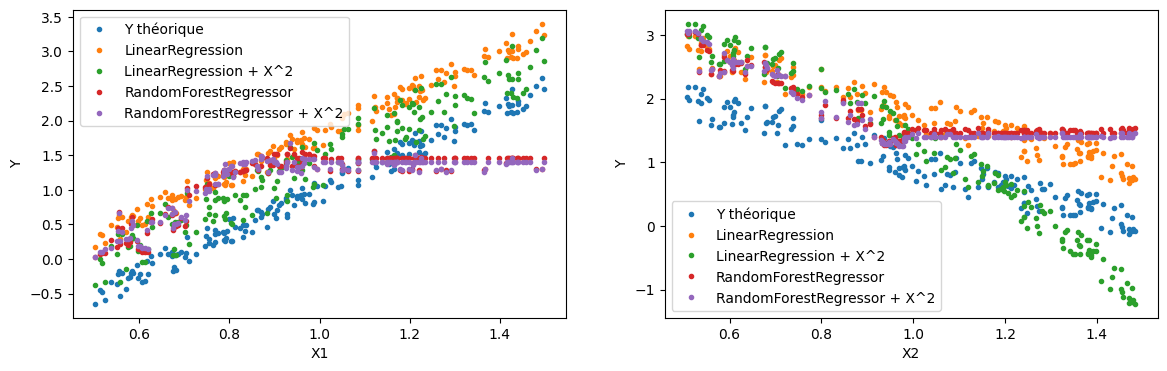

In [60]:
for model in [LR, LR2, rf, rf2]:
    name = model.__class__.__name__
    try:
        pred2 = model.predict(X_test2)
    except Exception:
        pred2 = model.predict(poly.transform(X_test2))
        name += " + X^2"
    ax[0].plot(X_test2[index2, 0], pred2[index2], '.', label=name)
    ax[1].plot(X_test2[index1, 1], pred2[index1], '.', label=name)
    
ax[0].legend()
ax[1].legend()

fig

The graph studies the model variables according to one coordinate, while restricting the other to a given interval. We can see immediately that the random forest becomes constant beyond a certain threshold. Once again, this is quite normal, since the learning base only contains $X_1, X_2$ in the interval $[0, 1]$. Apart from that, each decision tree produces a constant value, simply because they are staircase functions: a random forest is an average of staircase functions, and is therefore bounded. As for the first linear regression, it cannot capture second-degree effects; it is linear with respect to the initial variables. It deviates less, but still deviates from the variable to be predicted.

The aim of this exercise is to illustrate that a machine learning model is estimated on a dataset that follows a certain distribution. When the data on which the model is used to predict no longer follows this distribution, the models return answers that are likely to be wrong, in different ways depending on the model.

This is why we say that machine learning models need to be relearned regularly, especially if they are applied to data generated by human activity and not data derived from physical problems.

## 7. Overfitting

**Illustrate overlearning on the ``X_train`` dataset by varying the depth of a decision tree**.


In [64]:
from sklearn.tree import DecisionTreeRegressor

res = []
for md in range(1, 20):
    tree = DecisionTreeRegressor(max_depth=md)
    tree.fit(X_train, y_train)
    r2_train = r2_score(y_train, tree.predict(X_train))
    r2_test = r2_score(y_test, tree.predict(X_test))
    res.append(dict(depth=md, r2_train=r2_train, r2_test=r2_test))

df = pandas.DataFrame(res)
df.head()

,depth,r2_train,r2_test
0,1,0.473510,0.474573
1,2,0.719949,0.694296
2,3,0.843151,0.827940
3,4,0.903146,0.870707
4,5,0.934554,0.897122


Text(0.5, 1.0, 'R2 evolution along depth')

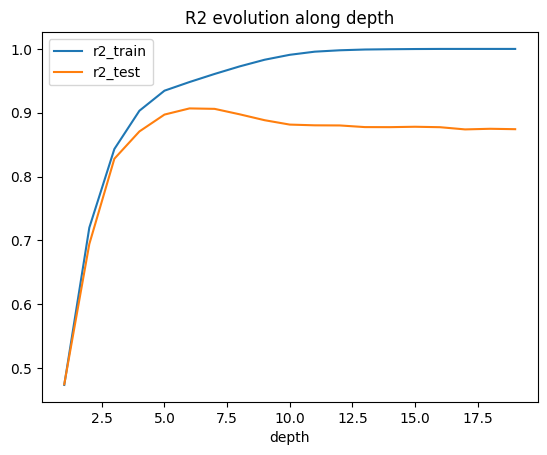

: 

In [ ]:
ax = df.plot(x='depth', y=['r2_train', 'r2_test'])
ax.set_title("R2 evolution along depth")

## 8. Feature number increase

### Lasso and Ridge Regression Regularization

**Lasso Regression (L1 Regularization):**

Lasso regression adds a penalty equal to the absolute value of the magnitude of coefficients to the loss function. This type of regularization can shrink some coefficients to zero, effectively performing feature selection. The loss function for Lasso regression is:

$$
L(\beta) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} |\beta_j|
$$

where:
- $ y_i $ is the actual value.
- $ \hat{y}_i $ is the predicted value.
- $ \beta_j $ are the coefficients.
- $ \lambda $ is the regularization parameter that controls the strength of the penalty.

**Ridge Regression (L2 Regularization):**

Ridge regression adds a penalty equal to the square of the magnitude of coefficients to the loss function. This type of regularization can shrink coefficients but does not set them to zero. The loss function for Ridge regression is:

$$
L(\beta) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} \beta_j^2
$$

where:
- $ y_i $ is the actual value.
- $ \hat{y}_i $ is the predicted value.
- $ \beta_j $ are the coefficients.
- $ \lambda $ is the regularization parameter that controls the strength of the penalty.

**Comparison:**

- **Lasso Regression** can be used for feature selection as it can shrink some coefficients to zero.
- **Ridge Regression** is useful when you have multicollinearity in your data as it can shrink coefficients but does not eliminate any features.
- Both methods help to prevent overfitting by adding a penalty to the loss function, which discourages large coefficients.

**Choosing between Lasso and Ridge:**

- Use **Lasso** when you want to perform feature selection and have a sparse model.
- Use **Ridge** when you want to keep all features but reduce the impact of less important ones.

**Elastic Net:**

Elastic Net is a combination of both Lasso and Ridge regression. It adds both L1 and L2 penalties to the loss function:

$$
L(\beta) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda_1 \sum_{j=1}^{p} |\beta_j| + \lambda_2 \sum_{j=1}^{p} \beta_j^2
$$

This method can be useful when you have many correlated features.

**Observe the impact of regularizing the coefficients of a logistic regression as the number of features increases**.
    

In [ ]:
from sklearn.linear_model import Ridge, Lasso
import numpy.linalg as nplin
import numpy

def non_nuls_coeff(coef):
    return sum(numpy.abs(coef) > 0.001)

res = []
for d in range(1, 21):
    poly = PolynomialFeatures(degree=d)    
    poly.fit(X_train)
    X_test2 = poly.transform(X_test)
    
    reg = LinearRegression()
    reg.fit(poly.transform(X_train), y_train)
    r2_reg = r2_score(y_test, reg.predict(X_test2))
    
    rid = Ridge(alpha=10)
    rid.fit(poly.transform(X_train), y_train)
    r2_rid = r2_score(y_test, rid.predict(X_test2))
    
    las = Lasso(alpha=0.01)
    las.fit(poly.transform(X_train), y_train)
    r2_las = r2_score(y_test, las.predict(X_test2))
    
    res.append(dict(degre=d, nb_features=X_test2.shape[1],
                    r2_reg=r2_reg, r2_las=r2_las, r2_rid=r2_rid,
                    norm_reg=nplin.norm(reg.coef_),
                    norm_rid=nplin.norm(rid.coef_),
                    norm_las=nplin.norm(las.coef_),
                    nnul_reg=non_nuls_coeff(reg.coef_),
                    nnul_rid=non_nuls_coeff(rid.coef_),
                    nnul_las=non_nuls_coeff(las.coef_),
                    ))

df = pandas.DataFrame(res)
df

,degre,nb_features,r2_reg,r2_las,r2_rid,norm_reg,norm_rid,norm_las,nnul_reg,nnul_rid,nnul_las
0,1,3,0.913263,0.909266,0.893963,3.580519e+00,3.128480,3.419882,2,2,2
1,2,6,0.934971,0.932088,0.914872,3.473067e+00,2.396091,3.399629,5,5,3
2,3,10,0.935074,0.932087,0.915563,3.484106e+00,2.143729,3.399580,9,9,3
3,4,15,0.934442,0.932087,0.917041,9.322595e+00,2.090001,3.399571,14,14,3
4,5,21,0.930070,0.932087,0.918873,9.181281e+01,2.083176,3.399593,20,20,3
5,6,28,0.929794,0.932087,0.920118,3.175696e+02,2.077210,3.399598,27,27,3
6,7,36,0.928758,0.932087,0.920717,1.785736e+03,2.066194,3.399598,35,35,3
7,8,45,0.924507,0.932087,0.920890,1.242673e+04,2.052707,3.399598,44,44,3
8,9,55,0.920459,0.932087,0.920847,9.101345e+04,2.039428,3.399598,54,54,3
9,10,66,0.921080,0.932087,0.920725,5.574203e+05,2.027815,3.399598,65,63,3


Text(0.5, 1.0, 'Number of non null coefficients')

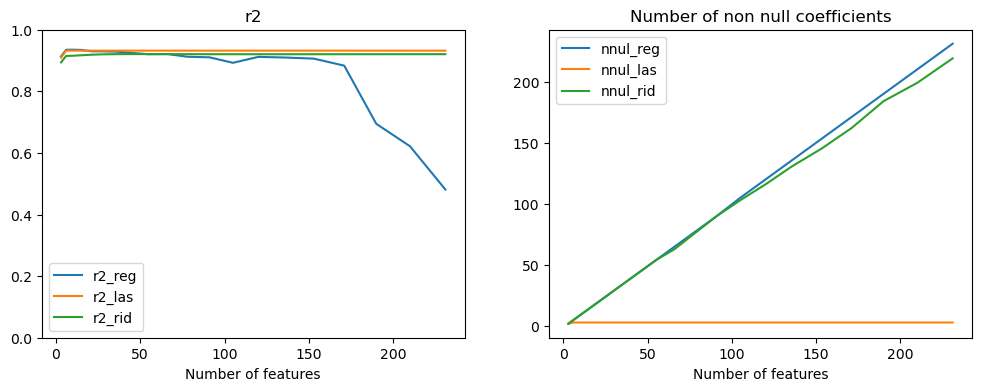

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df.plot(x="nb_features", y=["r2_reg", "r2_las", "r2_rid"], ax=ax[0])
ax[0].set_xlabel("Number of features")
ax[0].set_ylim([0, 1])
ax[0].set_title("r2")
df.plot(x="nb_features", y=["nnul_reg", "nnul_las", "nnul_rid"], ax=ax[1])
ax[1].set_xlabel("Number of features")
ax[1].set_title("Number of non null coefficients")